### Botlikh morphological transducer: precision and recall on the annotated words of the corpus

The analyses that the transducer gives for the words of the Spoken corpus of Botlikh were checked by hand: every analysis was marked as right (it agrees with the gloss of the corpus) or wrong. This notebook compares the two versions of the transducer with this annotation and computes precision, recall, F1 and accuracy, for all words and for every part of speech, counted by tokens and by entries.

Input: `evaluation/corpus/botlikh_corpus_words.xlsx` (the words of the corpus) and `evaluation/corpus/botlikh_corpus_annotation.tsv` (the annotation).

**How to run.** Open the notebook in Google Colab and choose *Runtime → Run all*. The notebook installs `lexd` and HFST, takes the transducer, compiles it from the sources and then does the evaluation. Nothing in the notebook is random: the same sources and the same input file always give the same output. Checksums of the sources, of the input file and of the results are printed, so two runs can be compared directly.

#### 1. Settings

* `GITHUB_URL`: the repository with the transducer and the evaluation data.
* `GITHUB_COMMIT`: an optional commit hash that pins the exact version of the transducer.
* `PROJECT_DIR`: the folder of the repository (with the `Makefile` of the transducer).
* `OUT_DIR`: the folder for all tables and figures.
* `VARIANTS`: the two versions of the transducer that are compared. In the first one no clitics are allowed; in the second one a chain of up to three clitics can follow a word of any part of speech.
* `ANNOTATED_VARIANT`: the version of the transducer whose analyses were annotated (clitics after all words). The analyses of the version without clitics are a subset of them, so the same annotation serves both versions.
* `MIN_WORDS`: a part of speech with fewer tokens is left out of the figures (it stays in the tables).


In [1]:
GITHUB_URL = 'https://github.com/mbogautdinov/botlikh_transducer'
GITHUB_COMMIT = ''

PROJECT_DIR = 'botlikh_transducer'
OUT_DIR = 'eval_output'

VARIANTS = {
    'no clitics': 'bot_noclitics_analyzer',
    'all clitics': 'bot_allclitics_analyzer',
}

ANNOTATED_VARIANT = 'all clitics'
MIN_WORDS = 5

ANALYZERS = sorted(set(VARIANTS.values()))


#### 2. Tools

The transducer is compiled with `lexd` and HFST. If they are not installed yet, the cell installs them: first from the standard Ubuntu packages and, if `lexd` is not found there, from the package repository of the Apertium project. The helper `sh` runs a shell command, prints the end of its output and stops the notebook if the command fails. The versions of the tools are printed at the end, so that they are saved together with the results.


In [2]:
import os
import shutil
import subprocess


def sh(cmd, check=True, tail=3000):
    r = subprocess.run(cmd, shell=True, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    if r.stdout.strip():
        print(r.stdout[-tail:])
    if check and r.returncode != 0:
        raise RuntimeError('command failed: ' + cmd)


TOOLS = ('lexd', 'hfst-twolc', 'hfst-compose-intersect', 'hfst-lookup', 'make')

if any(shutil.which(t) is None for t in TOOLS):
    sh('apt-get update -qq && apt-get install -y -qq hfst make', check=False)
    if shutil.which('lexd') is None:
        sh('apt-get install -y -qq lexd', check=False)
    if shutil.which('lexd') is None or shutil.which('hfst-twolc') is None:
        sh('wget -q https://apertium.projectjj.com/apt/install-nightly.sh -O /tmp/install-nightly.sh'
           ' && bash /tmp/install-nightly.sh && apt-get install -y -qq hfst lexd')

missing = [t for t in TOOLS if shutil.which(t) is None]
assert not missing, 'not installed: ' + ', '.join(missing)

sh('lexd --version 2>&1 | head -1; hfst-lookup --version 2>&1 | head -1; make --version | head -1; python3 --version')


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libfoma0t64:amd64.
(Reading database ... 
(Reading database ... 5%
(Reading database ... 10%
(Reading database ... 15%
(Reading database ... 20%
(Reading database ... 25%
(Reading database ... 30%
(Reading database ... 35%
(Reading database ... 40%
(Reading database ... 45%
(Reading database ... 50%
(Reading database ... 55%
(Reading database ... 60%
(Reading database ... 65%
(Reading database ... 70%
(Reading database ... 75%
(Reading database ... 80%
(Reading database ... 85%
(Reading database ... 90%
(Reading database ... 95%
(Reading database ... 100%
(Reading database ... 122815 files and directories currently installed.)
Preparing to unpack .../libfoma0t64_1%3a0.10.0+s311-1.2build2_amd64.deb ...
Unpacking libfoma0t64:amd64 (1:0.10.0+s311-1.2build2) ...
Se

#### 3. The transducer

The repository is cloned from GitHub. If the folder `PROJECT_DIR` already exists (for example, a local clone), it is used as it is. The commit of the repository is printed, so that the results can be traced to an exact version of the transducer.


In [3]:
if not os.path.isdir(PROJECT_DIR):
    assert GITHUB_URL, 'set GITHUB_URL in the settings'
    sh('git clone -q ' + GITHUB_URL + ' ' + PROJECT_DIR)
    if GITHUB_COMMIT:
        sh('git -C ' + PROJECT_DIR + ' checkout -q ' + GITHUB_COMMIT)

assert os.path.isfile(os.path.join(PROJECT_DIR, 'Makefile')), 'the folder with the transducer was not found'
os.makedirs(OUT_DIR, exist_ok=True)
print('project:', os.path.abspath(PROJECT_DIR))
sh('git -C ' + PROJECT_DIR + ' log -1 --format="commit %H (%ad)" --date=short', check=False)


project: /content/botlikh_transducer
commit 5f83d2e50392dd13d60cdc540cf060fdc84d3dbf (2026-10-06)



The transducer is rebuilt from scratch from the `lexd` and `twol` sources. `make` builds the analyzers, among them the two versions that are compared here. No Python scripts are called at this step: the lexicons are a part of the repository.


In [4]:
sh('make -C ' + PROJECT_DIR + ' clean')
sh('make -C ' + PROJECT_DIR, tail=600)
sh('ls -la ' + ' '.join(os.path.join(PROJECT_DIR, a + '.hfstol') for a in ANALYZERS))


make: Entering directory '/content/botlikh_transducer'
rm -f *.hfst *.hfstol *.tmp */*_twol.hfst
make: Leaving directory '/content/botlikh_transducer'

ot_allclitics_hosts_cop3.tmp | hfst-concatenate -1 - -2 bot_clitics01_generator.hfst | hfst-minimize -o bot_allclitics_hosts_cop.hfst
rm -f bot_allclitics_hosts_cop1.tmp bot_allclitics_hosts_cop2.tmp bot_allclitics_hosts_cop3.tmp
hfst-union bot_allclitics_hosts.hfst bot_allclitics_hosts_cop.hfst | hfst-union -1 - -2 bot_clitics_isolated.hfst | hfst-minimize -o bot_allclitics_generator.hfst
hfst-invert bot_allclitics_generator.hfst -o bot_allclitics_analyzer.hfst
hfst-fst2fst -O bot_allclitics_analyzer.hfst -o bot_allclitics_analyzer.hfstol
make: Leaving directory '/content/botlikh_transducer'

-rw-r--r-- 1 root root 514697 Oct  6 19:45 botlikh_transducer/bot_allclitics_analyzer.hfstol
-rw-r--r-- 1 root root 484299 Oct  6 19:45 botlikh_transducer/bot_noclitics_analyzer.hfstol



The cell below prints one checksum for all sources of the transducer (the `lexd` and `twol` files and the `Makefile`) and one for the input data. If these two values are the same on two computers, all results below must be the same as well.

The third value is the checksum of the annotation.


In [5]:
DATA = os.path.join(PROJECT_DIR, 'evaluation', 'corpus', 'botlikh_corpus_words.xlsx')
import glob
import hashlib


def sha256(path):
    with open(path, 'rb') as f:
        return hashlib.sha256(f.read()).hexdigest()


src_files = sorted(
    glob.glob(os.path.join(PROJECT_DIR, '*', '*.lexd'))
    + glob.glob(os.path.join(PROJECT_DIR, '*', '*.twol'))
    + glob.glob(os.path.join(PROJECT_DIR, '*.twol'))
    + [os.path.join(PROJECT_DIR, 'Makefile')]
)
h = hashlib.sha256()
for p in src_files:
    h.update(os.path.relpath(p, PROJECT_DIR).encode('utf-8'))
    with open(p, 'rb') as f:
        h.update(f.read())

print('transducer sources:', len(src_files), 'files, sha256', h.hexdigest())
print('input data:        ', os.path.relpath(DATA, PROJECT_DIR), 'sha256', sha256(DATA))

ANNOTATION = os.path.join(PROJECT_DIR, 'evaluation', 'corpus', 'botlikh_corpus_annotation.tsv')
print('annotation:        ', os.path.relpath(ANNOTATION, PROJECT_DIR), 'sha256', sha256(ANNOTATION))


transducer sources: 21 files, sha256 ab2deda3f1694b26a2fd7528e82ae8ee561a9e42d0896086d08e7bd06869064b
input data:         evaluation/corpus/botlikh_corpus_words.xlsx sha256 12e9c112fd57cd3ea40902663c4c37684cae15bceff7703d38ba83ec1eb26984
annotation:         evaluation/corpus/botlikh_corpus_annotation.tsv sha256 cc4e7749bb0e2e1749ff5d172a592469d50e9195a8f420356fd271ed782cd535


The function `lookup` sends a list of word forms to `hfst-lookup` and returns a dictionary `{form: [analyses]}`. An empty list means that the form is not recognised. The analyses of a form are sorted, so the order does not depend on the version of HFST.

Two more helpers read an analysis: `proposed_pos` returns the parts of speech that the analyses of a form propose (the first tag in capitals, such as `N` or `ADV`), and `clitic_tags` returns the tags of the clitics (the tags after `=`). A clitic that is written as a separate word has an analysis without a stem (`=<quot>`); it is counted as `CLITIC`.


In [6]:
import re


def lookup(analyzer, forms):
    forms = [f for f in dict.fromkeys(forms) if f and not any(ch.isspace() for ch in f)]
    path = os.path.join(PROJECT_DIR, analyzer + '.hfstol')
    r = subprocess.run(['hfst-lookup', '-q', path], input='\n'.join(forms) + '\n',
                       capture_output=True, text=True, check=True)
    res = {f: [] for f in forms}
    for line in r.stdout.splitlines():
        parts = line.split('\t')
        if len(parts) >= 2 and parts[0] in res and not parts[1].endswith('+?'):
            if parts[1] not in res[parts[0]]:
                res[parts[0]].append(parts[1])
    return {f: sorted(a) for f, a in res.items()}


POS_TAG = re.compile(r'<([A-Z]+)>')
CLITIC_TAG = re.compile(r'=<([^>]+)>')


def proposed_pos(analyses):
    found = set()
    for a in analyses:
        m = POS_TAG.search(a)
        if m:
            found.add(m.group(1))
        elif a.startswith('='):
            found.add('CLITIC')
    return sorted(found)


def clitic_tags(analyses):
    return sorted({t for a in analyses for t in CLITIC_TAG.findall(a)})


for name, analyzer in VARIANTS.items():
    print(name, lookup(analyzer, ['хъуча', 'хъучиди', 'хъучала', 'гьикьила']))


no clitics {'хъуча': ['хъуча<N>', 'хъуча<N>><sup.lat>'], 'хъучиди': ['хъуча<N>><erg>'], 'хъучала': [], 'гьикьила': []}
all clitics {'хъуча': ['хъуча<N>', 'хъуча<N>><sup.lat>'], 'хъучиди': ['хъуча<N>><erg>'], 'хъучала': ['хъуча<N>=<add>', 'хъуча<N>=<cq>', 'хъуча<N>><sup.lat>=<add>', 'хъуча<N>><sup.lat>=<cq>'], 'гьикьила': ['гьикьи<ADV>=<add>', 'гьикьи<ADV>=<cq>', 'гьикьи<POSTP>=<add>', 'гьикьи<POSTP>=<cq>']}


#### 4. Figures: common style

All figures use the same two colours: blue for the transducer without clitics and orange for the transducer with clitics after all words. The pair was checked for the common forms of colour blindness. Grey is used for context, such as the total number of words. Values are also printed in tables next to every figure, so no number has to be read from a colour alone.

`grouped_bars` draws one group of bars per row of a table and one bar per transducer; `finish` adds the title, the axis label and the legend and removes everything that is not data.

One more set of colours is used in this notebook for the outcome of a word: green for a word with a correct analysis, red for a word that has only wrong analyses, grey for a word without an analysis. The numbers are printed in the bars, so the colour is not the only sign.


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

COLORS = {'no clitics': '#2a78d6', 'all clitics': '#eb6834'}
GREY = '#c3c2b7'
INK = '#0b0b0b'
INK2 = '#52514e'
MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'
BLUES = LinearSegmentedColormap.from_list(
    'blues', [SURFACE, '#cde2fb', '#86b6ef', '#3987e5', '#1c5cab', '#0d366b'])

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.edgecolor': GREY, 'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'xtick.labelcolor': INK2, 'ytick.labelcolor': INK2,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False, 'figure.dpi': 110,
})


def finish(ax, title, label='', horizontal=False, legend=False):
    ax.set_title(title, pad=10)
    ax.set_axisbelow(True)
    if horizontal:
        ax.set_xlabel(label)
        ax.grid(axis='x', color=GRID, linewidth=0.8)
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(axis='both', length=0)
    else:
        ax.set_ylabel(label)
        ax.grid(axis='y', color=GRID, linewidth=0.8)
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='both', length=0)
    if legend:
        ax.legend(loc='best', handlelength=1.2, handleheight=1.0, borderaxespad=0.2)


def grouped_bars(ax, table, horizontal=False, fmt='{:.0f}', labels=True, total=None):
    groups = list(table.index)
    series = list(table.columns)
    pos = np.arange(len(groups))
    width = 0.8 / len(series)
    if total is not None:
        if horizontal:
            ax.barh(pos, total.values, height=0.86, color=GRID, label='all words', zorder=1)
        else:
            ax.bar(pos, total.values, width=0.86, color=GRID, label='all words', zorder=1)
    for i, s in enumerate(series):
        offset = (i - (len(series) - 1) / 2) * width
        values = table[s].values
        if horizontal:
            bars = ax.barh(pos + offset, values, height=width, color=COLORS[s], edgecolor=SURFACE,
                           linewidth=1.2, label=s, zorder=2)
        else:
            bars = ax.bar(pos + offset, values, width=width, color=COLORS[s], edgecolor=SURFACE,
                          linewidth=1.2, label=s, zorder=2)
        if labels:
            ax.bar_label(bars, labels=[fmt.format(v) for v in values], padding=2, fontsize=8, color=INK2)
    if horizontal:
        ax.set_yticks(pos)
        ax.set_yticklabels(groups)
        ax.invert_yaxis()
        ax.margins(x=0.12)
    else:
        ax.set_xticks(pos)
        ax.set_xticklabels(groups)
        ax.margins(y=0.12)


def save_figure(fig, name):
    for ext in ('png', 'pdf'):
        fig.savefig(os.path.join(OUT_DIR, name + '.' + ext), dpi=200, bbox_inches='tight')

OUTCOMES = ['correct analysis', 'only wrong analyses', 'no analysis']
OUTCOME_COLORS = {'correct analysis': '#0ca30c', 'only wrong analyses': '#d03b3b', 'no analysis': GREY}
OUTCOME_INK = {'correct analysis': INK, 'only wrong analyses': 'white', 'no analysis': INK}


#### 5. The words of the corpus

The words are read and prepared exactly as in the first notebook: punctuation at the edges is removed, the first letter is made lower-case, and the rows that are not Botlikh words, the empty rows and the words with a question mark in the gloss are left out (column `excluded`).

The unit of the evaluation is an **entry**: a word form in one reading, that is, a combination of form, segmentation, gloss and part of speech. All tokens of an entry get the same analyses, and an analysis is right or wrong for all of them. The table `entries` has one row per entry: `tokens` is the number of its occurrences, `row` is the row of its first occurrence in the input file.


In [8]:
import pandas as pd

COLUMNS = {
    'Язык слова': 'language',
    'Слово': 'word',
    'Сегментация': 'segmentation',
    'Глосса': 'gloss',
    'Часть речи': 'pos',
    'Предложение (ботлихский)': 'sentence',
    'Предложение (русский)': 'translation_ru',
    'Предложение (английский)': 'translation_en',
    'Документ': 'document',
    'Говорящий': 'speaker',
    '№ предложения': 'sentence_nr',
    '№ слова': 'word_nr',
    'Примечание': 'note',
}


PUNCTUATION = ' .,;:!?…'


def prepare(word):
    w = str(word).strip(PUNCTUATION)
    return w[:1].lower() + w[1:]


words = pd.read_excel(DATA).rename(columns=COLUMNS)

words['excluded'] = ''
words.loc[words['language'] != 'Botlikh', 'excluded'] = 'not Botlikh'
words.loc[(words['excluded'] == '') & words['gloss'].isna() & words['pos'].isna(), 'excluded'] = 'empty row'
words.loc[(words['excluded'] == '') & words['gloss'].fillna('').str.contains('?', regex=False), 'excluded'] = 'unclear gloss'

words['pos'] = words['pos'].fillna('not marked')
words['form'] = words['word'].map(prepare)

print(len(words), 'rows;', words['language'].value_counts().to_dict())
print('left out:', words.loc[words['excluded'] != '', 'excluded'].value_counts().to_dict())
print('Botlikh words in the statistics:', int((words['excluded'] == '').sum()))

botlikh = words[words['excluded'] == ''].copy()
botlikh['row'] = botlikh.index + 2
botlikh[['segmentation', 'gloss']] = botlikh[['segmentation', 'gloss']].fillna('')

entries = (
    botlikh.groupby(['pos', 'form', 'segmentation', 'gloss'], sort=False)
    .agg(tokens=('row', 'size'), row=('row', 'min')).reset_index()
)
print(len(botlikh), 'tokens,', len(entries), 'entries')
entries.head(10)


1582 rows; {'Botlikh': 1309, 'RUS': 223, 'AVAR': 50}
left out: {'not Botlikh': 273, 'unclear gloss': 30, 'empty row': 6}
Botlikh words in the statistics: 1273
1273 tokens, 743 entries


,pos,form,segmentation,gloss,tokens,row
0,noun,жола,жола,twig,2,2
1,pron,эпихула,эпи=ху.ла,why=inan.cq,1,3
2,noun,гъургъуну,гъургъуну,fairy_pigeon,16,4
3,pron,гьаб,гьа-б,dem-n,15,5
4,particle,ида,ида,cop,25,6
5,noun,гъургъулъи,гъургъу-лъи,pigeon-gen,1,7
6,noun,щикибалъи,щикиб-а-лъи,bird-obl-gen,1,8
7,v,масихаб,мас-и-ха-б,tell-is-inan.prs.ptcp-n,2,9
8,pron,индулда,инду-л-да,refl.pl-an.pl-int,1,10
9,noun,макӏилуй,макӏи-лу-й,child-pl.obl-dat,2,11


#### 6. Analyses and the annotation

Every form is analysed with both versions of the transducer.

The annotation has one row per analysis of an entry (for the version with clitics after all words). The column `correct` is `1` for an analysis that agrees with the gloss of the corpus and `0` for a wrong one. The entry is found by the column `row`, the analysis by the column `analysis`. For the words that have no part of speech in the corpus, the part of speech was added during the annotation; it is taken from the annotation.

The annotation belongs to one version of the transducer. The cell checks that the transducer gives exactly the annotated analyses: no analysis without a label and no label without an analysis. If the sources of the transducer are changed, this check fails, and the new analyses have to be annotated first.


In [9]:
results = {name: lookup(analyzer, entries['form'].tolist()) for name, analyzer in VARIANTS.items()}

annotation = pd.read_csv(ANNOTATION, sep='\t', dtype=str, keep_default_na=False)
annotation['row'] = annotation['row'].astype(int)
annotation['correct'] = annotation['correct'].astype(int)
assert set(annotation['correct']) <= {0, 1}, 'the column correct must have 0 or 1'
label = {(r, a): c for r, a, c in zip(annotation['row'], annotation['analysis'], annotation['correct'])}
assert len(label) == len(annotation), 'an analysis is annotated twice'

produced = {name: {(r, a) for r, f in zip(entries['row'], entries['form']) for a in results[name].get(f, [])} for name in VARIANTS}
missing = produced[ANNOTATED_VARIANT] - set(label)
unused = set(label) - produced[ANNOTATED_VARIANT]
print(len(label), 'annotated analyses:', sum(label.values()), 'right,', len(label) - sum(label.values()), 'wrong')
print('analyses without a label:', len(missing), '; labels without an analysis:', len(unused))
assert not missing and not unused, 'the annotation was made for another version of the transducer'
for name in VARIANTS:
    assert produced[name] <= set(label), 'the version ' + name + ' has analyses that are not annotated'

pos_annotated = dict(zip(annotation['row'], annotation['pos']))
entries['pos'] = [pos_annotated.get(r, p) for r, p in zip(entries['row'], entries['pos'])]


1187 annotated analyses: 434 right, 753 wrong
analyses without a label: 0 ; labels without an analysis: 0


The table `evaluated` has one row per entry and version of the transducer: the number of analyses, how many of them are right (`correct`) and wrong (`wrong`), and the outcome for the word:

* `correct analysis`: at least one analysis is right;
* `only wrong analyses`: the word is recognised, but no analysis is right;
* `no analysis`: the word is not recognised.


In [10]:
rows = []
for name in VARIANTS:
    for e in entries.itertuples():
        labels = [label[(e.row, a)] for a in results[name].get(e.form, [])]
        rows.append({'transducer': name, 'pos': e.pos, 'form': e.form, 'segmentation': e.segmentation, 'gloss': e.gloss,
                     'tokens': e.tokens, 'analyses': len(labels), 'correct': sum(labels), 'wrong': len(labels) - sum(labels)})
evaluated = pd.DataFrame(rows)
evaluated['outcome'] = np.where(evaluated['correct'] > 0, OUTCOMES[0], np.where(evaluated['analyses'] > 0, OUTCOMES[1], OUTCOMES[2]))

pos_order = entries.groupby('pos')['tokens'].sum().sort_values(ascending=False, kind='stable').index.tolist()
evaluated[evaluated['transducer'] == ANNOTATED_VARIANT].head(10)


,transducer,pos,form,segmentation,gloss,tokens,analyses,correct,wrong,outcome
743,all clitics,noun,жола,жола,twig,2,2,1,1,correct analysis
744,all clitics,pron,эпихула,эпи=ху.ла,why=inan.cq,1,2,1,1,correct analysis
745,all clitics,noun,гъургъуну,гъургъуну,fairy_pigeon,16,3,1,2,correct analysis
746,all clitics,pron,гьаб,гьа-б,dem-n,15,3,1,2,correct analysis
747,all clitics,particle,ида,ида,cop,25,4,1,3,correct analysis
748,all clitics,noun,гъургъулъи,гъургъу-лъи,pigeon-gen,1,2,1,1,correct analysis
749,all clitics,noun,щикибалъи,щикиб-а-лъи,bird-obl-gen,1,2,1,1,correct analysis
750,all clitics,v,масихаб,мас-и-ха-б,tell-is-inan.prs.ptcp-n,2,2,0,2,only wrong analyses
751,all clitics,pron,индулда,инду-л-да,refl.pl-an.pl-int,1,1,1,0,correct analysis
752,all clitics,noun,макӏилуй,макӏи-лу-й,child-pl.obl-dat,2,3,1,2,correct analysis


#### 7. Metrics

The analyses of the transducer are compared with the gold standard, as in the confusion matrix of Kazakova and Moroz (2025, chapter 8):

* **TP** (true positives): analyses of the transducer that are right;
* **FP** (false positives): analyses of the transducer that are wrong;
* **FN** (false negatives): right analyses that the transducer does not give. The annotation only says which of the proposed analyses are right, so a missing analysis is counted once for every word without a right analysis (a word that is not recognised, or a word with wrong analyses only);
* **TN** (true negatives): words that have no analysis in the gold standard and get none from the transducer. There are no such words here: the words with an unclear gloss are left out, and every other word has a gloss. TN = 0.

From these numbers:

* precision = TP / (TP + FP): the share of right analyses among the analyses of the transducer;
* recall = TP / (TP + FN): the share of the right analyses that the transducer finds;
* F1 = 2 · TP / (2 · TP + FP + FN);
* accuracy = (TP + TN) / (TP + FP + FN + TN), which is TP / (TP + FP + FN) here.

Next to them the table gives the number of words, of recognised words and of words `with a correct analysis` (the correctly analysed forms).

Everything is counted in two ways (column `count`): by **token**, where an entry is counted as many times as it occurs in the corpus, and by **entry**, where every entry is counted once, so that frequent words do not decide the result. The groups are all words, all words without the verbs (verbs are not implemented in the transducer) and every part of speech of the corpus.


In [11]:
def confusion(df, count):
    w = df['tokens'] if count == 'token' else pd.Series(1, index=df.index)
    tp = int((w * df['correct']).sum())
    fp = int((w * df['wrong']).sum())
    fn = int(w[df['correct'] == 0].sum())
    return {
        'words': int(w.sum()),
        'recognised': int(w[df['analyses'] > 0].sum()),
        'with a correct analysis': int(w[df['correct'] > 0].sum()),
        'TP': tp, 'FP': fp, 'FN': fn,
        'precision': tp / (tp + fp) if tp + fp else float('nan'),
        'recall': tp / (tp + fn) if tp + fn else float('nan'),
        'F1': 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else float('nan'),
        'accuracy': tp / (tp + fp + fn) if tp + fp + fn else float('nan'),
    }


rows = []
for count in ('token', 'entry'):
    for name in VARIANTS:
        part = evaluated[evaluated['transducer'] == name]
        groups = [('all words', part), ('without verbs', part[part['pos'] != 'v'])] + [(p, part[part['pos'] == p]) for p in pos_order]
        for group, sub in groups:
            rows.append({'count': count, 'transducer': name, 'group': group, **confusion(sub, count)})
metrics = pd.DataFrame(rows)
RATIOS = ['precision', 'recall', 'F1', 'accuracy']

overall = metrics[metrics['group'].isin(['all words', 'without verbs'])].reset_index(drop=True)
overall.round(3)


,count,transducer,group,words,recognised,with a correct analysis,TP,FP,FN,precision,recall,F1,accuracy
0,token,no clitics,all words,1273,860,666,702,743,607,0.486,0.536,0.510,0.342
1,token,no clitics,without verbs,885,739,666,702,563,219,0.555,0.762,0.642,0.473
2,token,all clitics,all words,1273,1019,783,837,1296,490,0.392,0.631,0.484,0.319
3,token,all clitics,without verbs,885,845,783,837,1019,102,0.451,0.891,0.599,0.427
4,entry,no clitics,all words,743,427,309,326,383,434,0.460,0.429,0.444,0.285
5,entry,no clitics,without verbs,486,355,309,326,274,177,0.543,0.648,0.591,0.420
6,entry,all clitics,all words,743,551,409,434,753,334,0.366,0.565,0.444,0.285
7,entry,all clitics,without verbs,486,449,409,434,577,77,0.429,0.849,0.570,0.399


The same numbers for every part of speech of the corpus.


In [12]:
by_pos = metrics[metrics['group'].isin(pos_order)].reset_index(drop=True)
by_pos.round(3)


,count,transducer,group,words,recognised,with a correct analysis,TP,FP,FN,precision,recall,F1,accuracy
0,token,no clitics,v,388,121,0,0,180,388,0.000,0.000,0.000,0.000
1,token,no clitics,noun,349,267,254,262,245,95,0.517,0.734,0.606,0.435
2,token,no clitics,pron,217,185,175,175,194,42,0.474,0.806,0.597,0.426
3,token,no clitics,adv,156,144,115,128,64,41,0.667,0.757,0.709,0.549
4,token,no clitics,num,48,44,40,47,14,8,0.770,0.855,0.810,0.681
5,token,no clitics,particle,44,42,36,41,14,8,0.745,0.837,0.788,0.651
6,token,no clitics,adj,41,32,24,27,20,17,0.574,0.614,0.593,0.422
7,token,no clitics,name,16,14,14,14,8,2,0.636,0.875,0.737,0.583
8,token,no clitics,toponym,11,10,7,7,4,4,0.636,0.636,0.636,0.467
9,token,no clitics,not marked,2,0,0,0,0,2,NaN,0.000,0.000,0.000


#### 8. Figure: correctly analysed words

For every group of words and both versions of the transducer the bar shows how the words are split by outcome: a correct analysis, only wrong analyses, no analysis. The bars are scaled to 100%, the numbers in them are the numbers of words; the number of all words of the group is given in brackets. The figure is drawn twice: by tokens and by entries.


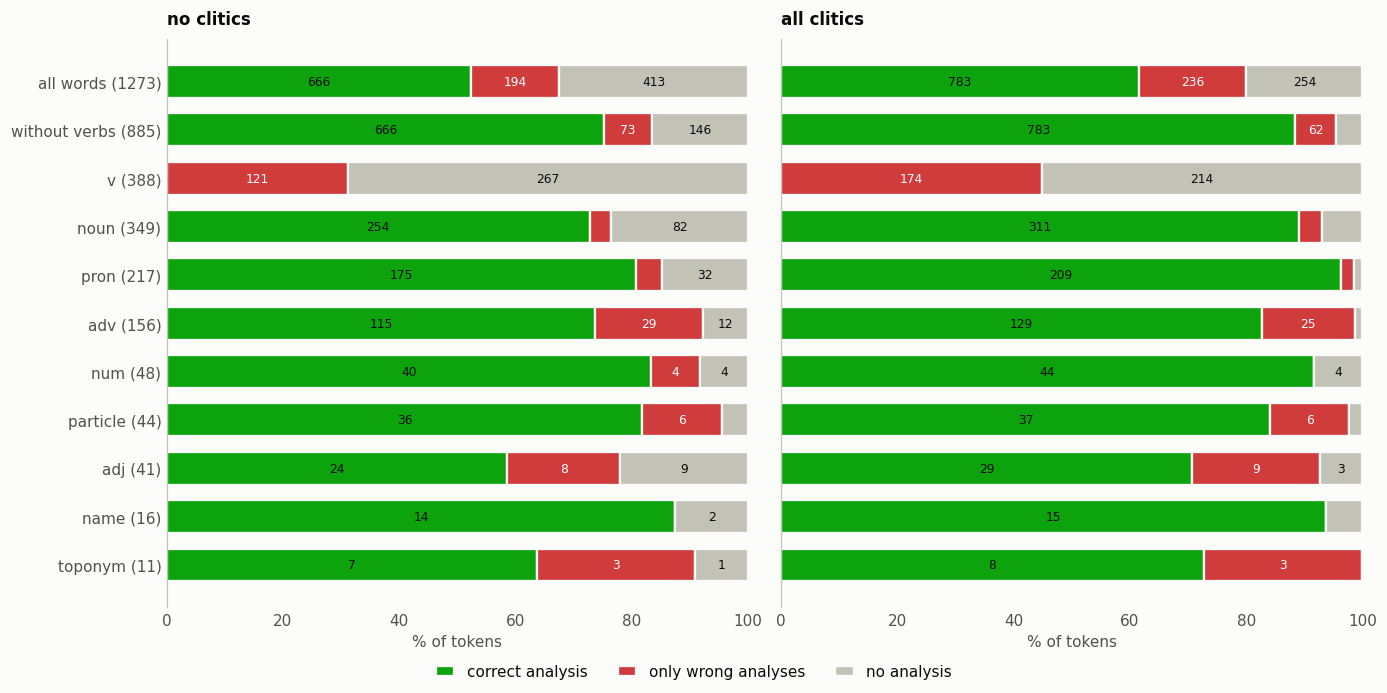

In [13]:
def shown_groups(count):
    tokens = entries.groupby('pos')['tokens'].sum()
    return ['all words', 'without verbs'] + [p for p in pos_order if tokens[p] >= MIN_WORDS]


def outcome_figure(count, name):
    groups = shown_groups(count)
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 0.42 * len(groups) + 1.6), constrained_layout=True, sharey=True)
    tables = {}
    for ax, variant in zip(axes, VARIANTS):
        part = evaluated[evaluated['transducer'] == variant]
        w = part['tokens'] if count == 'token' else pd.Series(1, index=part.index)
        rows = {}
        for g in groups:
            mask = pd.Series(True, index=part.index) if g == 'all words' else (part['pos'] != 'v') if g == 'without verbs' else (part['pos'] == g)
            rows[g] = [int(w[mask & (part['outcome'] == o)].sum()) for o in OUTCOMES]
        table = pd.DataFrame(rows, index=OUTCOMES).T
        tables[variant] = table
        share = 100 * table.div(table.sum(axis=1), axis=0)
        left = np.zeros(len(groups))
        pos = np.arange(len(groups))
        for o in OUTCOMES:
            bars = ax.barh(pos, share[o].values, left=left, height=0.68, color=OUTCOME_COLORS[o], edgecolor=SURFACE, linewidth=1.5, label=o)
            for k, (v, s) in enumerate(zip(table[o].values, share[o].values)):
                if s >= 7:
                    ax.text(left[k] + s / 2, k, str(v), ha='center', va='center', fontsize=8, color=OUTCOME_INK[o])
            left += share[o].values
        ax.set_yticks(pos)
        ax.set_yticklabels([g + ' (' + str(int(table.loc[g].sum())) + ')' for g in groups])
        ax.set_xlim(0, 100)
        finish(ax, variant, '% of ' + ('tokens' if count == 'token' else 'entries'), horizontal=True)
        ax.grid(False)
    axes[0].invert_yaxis()
    handles, names = axes[0].get_legend_handles_labels()
    fig.legend(handles, names, loc='outside lower center', ncol=3, handlelength=1.2)
    save_figure(fig, name)
    plt.show()
    return tables


outcome_tokens = outcome_figure('token', 'annotation_fig_outcome_tokens')


The same figure by entries.


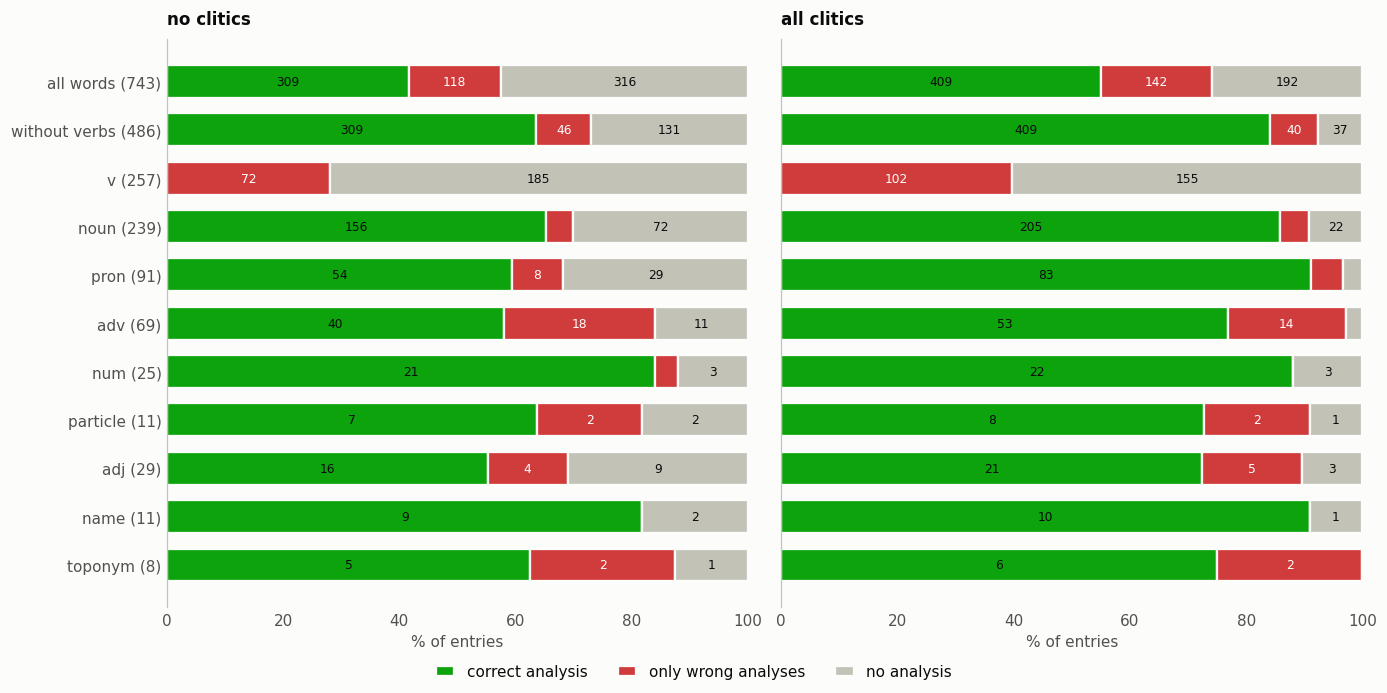

In [14]:
outcome_entries = outcome_figure('entry', 'annotation_fig_outcome_entries')


#### 9. Figure: precision and recall

The first two panels give the four measures for all words and for all words without the verbs; the other two give precision and recall for every part of speech (with at least `MIN_WORDS` tokens). Blue is the transducer without clitics, orange the transducer with clitics after all words, as in the other notebooks. The figure is drawn twice: by tokens and by entries.


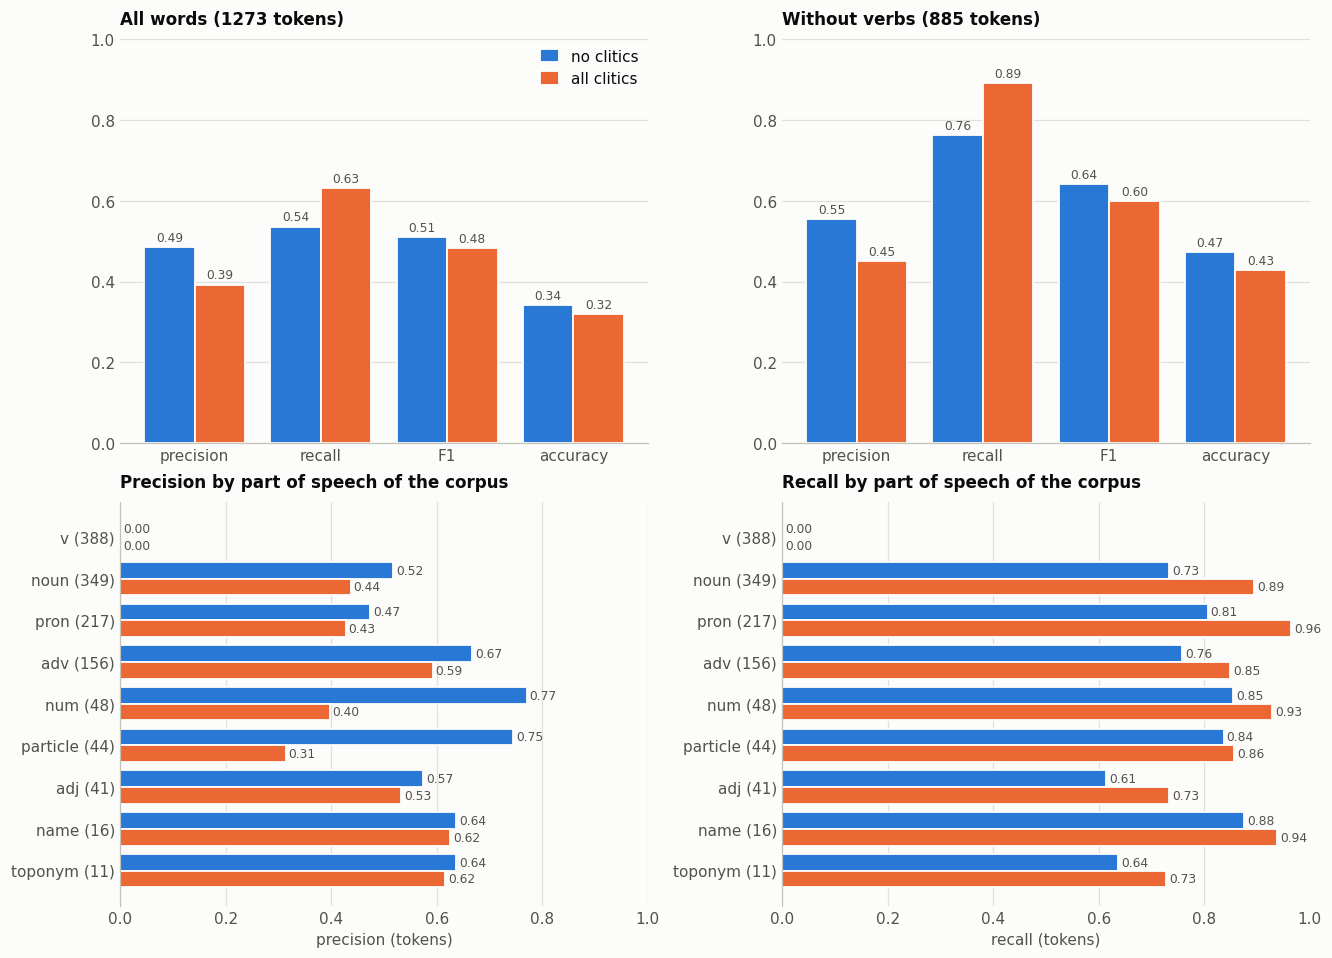

In [15]:
def ratio_table(count, groups, columns):
    part = metrics[(metrics['count'] == count) & metrics['group'].isin(groups)]
    out = {}
    for variant in VARIANTS:
        sub = part[part['transducer'] == variant].set_index('group').loc[groups]
        out[variant] = sub[columns]
    return out


def metrics_figure(count, name):
    unit = 'tokens' if count == 'token' else 'entries'
    fig, axes = plt.subplots(2, 2, figsize=(12, 8.6), constrained_layout=True)

    for ax, group in zip(axes[0], ['all words', 'without verbs']):
        table = pd.DataFrame({v: t.loc[group] for v, t in ratio_table(count, [group], RATIOS).items()})
        grouped_bars(ax, table, fmt='{:.2f}')
        ax.set_ylim(0, 1)
        words = int(metrics[(metrics['count'] == count) & (metrics['group'] == group)]['words'].iloc[0])
        finish(ax, group[:1].upper() + group[1:] + ' (' + str(words) + ' ' + unit + ')', '', legend=(group == 'all words'))

    groups = [g for g in shown_groups(count) if g not in ('all words', 'without verbs')]
    sizes = metrics[(metrics['count'] == count) & (metrics['transducer'] == ANNOTATED_VARIANT)].set_index('group')['words']
    for ax, measure in zip(axes[1], ['precision', 'recall']):
        table = pd.DataFrame({v: t[measure] for v, t in ratio_table(count, groups, [measure]).items()})
        table.index = [g + ' (' + str(int(sizes[g])) + ')' for g in groups]
        grouped_bars(ax, table.fillna(0), horizontal=True, fmt='{:.2f}')
        ax.set_xlim(0, 1)
        finish(ax, measure[:1].upper() + measure[1:] + ' by part of speech of the corpus', measure + ' (' + unit + ')', horizontal=True)

    save_figure(fig, name)
    plt.show()


metrics_figure('token', 'annotation_fig_metrics_tokens')


The same figure by entries.


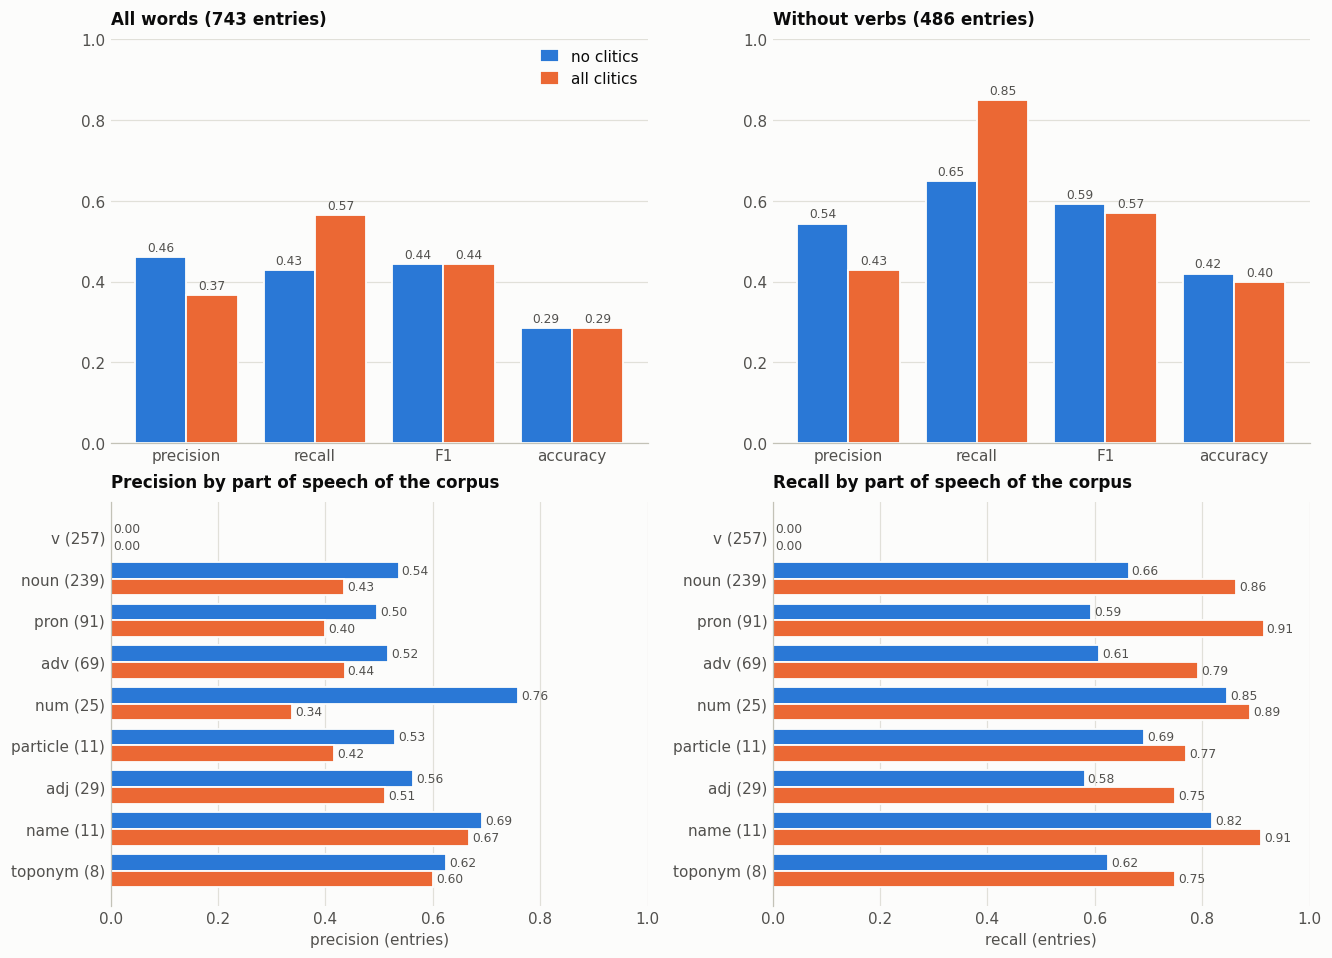

In [16]:
metrics_figure('entry', 'annotation_fig_metrics_entries')


#### 10. Words without a correct analysis

The entries that have no right analysis in the version with clitics after all words, the most frequent ones first: the words that are not recognised and the words that get only wrong analyses.


In [17]:
errors = (
    evaluated[(evaluated['transducer'] == ANNOTATED_VARIANT) & (evaluated['correct'] == 0)]
    .sort_values(['tokens', 'pos', 'form', 'gloss'], ascending=[False, True, True, True])
    [['pos', 'form', 'segmentation', 'gloss', 'tokens', 'analyses', 'outcome']].reset_index(drop=True)
)
errors.head(30)


,pos,form,segmentation,gloss,tokens,analyses,outcome
0,v,букӏа,б-укӏ-а,n-be-aor,18,1,only wrong analyses
1,v,игье,игь-е,do-hab,9,1,only wrong analyses
2,v,игьи,игь-и,do-inf,9,1,only wrong analyses
3,v,рукӏа,р-укӏ-а,an.pl-be-aor,9,0,no analysis
4,v,игьихаб,игь-и-ха-б,do-is-inan.prs.ptcp-n,6,2,only wrong analyses
5,adv,рорчӏами,р-орчӏами,an.pl-hello,5,1,only wrong analyses
6,particle,гучӏи,гу-чӏи,cop-neg,5,1,only wrong analyses
7,v,бацӏа,б-ацӏ-а,n-reach-aor,5,2,only wrong analyses
8,v,букӏаб,б-укӏ-а-б,n-be-pst.ptcp-n,5,2,only wrong analyses
9,v,букӏи,б-укӏ-и,n-be-inf,5,0,no analysis


The same words counted by part of speech and outcome, in entries and in tokens.


In [18]:
errors_by_pos = errors.groupby(['pos', 'outcome'])['tokens'].agg(entries='size', tokens='sum').unstack(fill_value=0)
errors_by_pos.columns = [unit + ': ' + outcome for unit, outcome in errors_by_pos.columns]
errors_by_pos = errors_by_pos.loc[[p for p in pos_order if p in errors_by_pos.index]]
errors_by_pos


,entries: no analysis,entries: only wrong analyses,tokens: no analysis,tokens: only wrong analyses
pos,,,,
v,155,102,214,174
noun,22,12,24,14
pron,3,5,3,5
adv,2,14,2,25
num,3,0,4,0
particle,1,2,1,6
adj,3,5,3,9
name,1,0,1,0
toponym,0,2,0,3


#### 11. Saving the results

The tables are saved as text files and together in one Excel file, the figures as PNG and PDF. A cell that begins with `=` is stored as text, so that Excel does not read it as a formula. The checksums of the text files are printed for comparison with another run.


In [19]:
tsv = {
    'annotation_metrics.tsv': metrics.round(4),
    'annotation_entries.tsv': evaluated,
    'annotation_no_correct_analysis.tsv': errors,
    'annotation_no_correct_analysis_by_pos.tsv': errors_by_pos.reset_index(),
}
for name, df in tsv.items():
    df.to_csv(os.path.join(OUT_DIR, name), sep='\t', index=False)
    print(sha256(os.path.join(OUT_DIR, name)), name)

with pd.ExcelWriter(os.path.join(OUT_DIR, 'annotation_results.xlsx'), engine='openpyxl') as xw:
    overall.round(4).to_excel(xw, sheet_name='overall', index=False)
    by_pos.round(4).to_excel(xw, sheet_name='by part of speech', index=False)
    evaluated.to_excel(xw, sheet_name='entries', index=False)
    errors.to_excel(xw, sheet_name='no correct analysis', index=False)
    for ws in xw.sheets.values():
        for row in ws.iter_rows(min_row=2):
            for c in row:
                if c.data_type == 'f':
                    c.data_type = 's'
print('written:', sorted(os.listdir(OUT_DIR)))


eb84500e00d2f7345b80ff531566125c6bf08f641163c5aff1f4ca9f695681e5 annotation_metrics.tsv
f15e56dbb6b3629a62c93591511da72b9b83bdf26045246b00da7c1aec7b9271 annotation_entries.tsv
b81dc3922e748afc8216550e57379659a9a65f369ad72fff41a3a893f3659873 annotation_no_correct_analysis.tsv
c4d15b61d440605e9b9d71493c8207f0088920e3beb6d9eff4ed6f5f88c6a9cc annotation_no_correct_analysis_by_pos.tsv
written: ['annotation_entries.tsv', 'annotation_fig_metrics_entries.pdf', 'annotation_fig_metrics_entries.png', 'annotation_fig_metrics_tokens.pdf', 'annotation_fig_metrics_tokens.png', 'annotation_fig_outcome_entries.pdf', 'annotation_fig_outcome_entries.png', 'annotation_fig_outcome_tokens.pdf', 'annotation_fig_outcome_tokens.png', 'annotation_metrics.tsv', 'annotation_no_correct_analysis.tsv', 'annotation_no_correct_analysis_by_pos.tsv', 'annotation_results.xlsx']


All tables and figures are in `OUT_DIR`. In Colab the folder is packed into one archive and downloaded.


In [20]:
shutil.make_archive(OUT_DIR, 'zip', OUT_DIR)
try:
    from google.colab import files
    files.download(OUT_DIR + '.zip')
except ImportError:
    print('results:', os.path.abspath(OUT_DIR))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>